In [2]:
import numpy as np
import scipy
import scipy.special
from scipy.fft import fft2, fftfreq, ifft2, fftshift, ifftshift
import matplotlib.pyplot as plt
from IPython.display import display
import threading
from io import StringIO 
import sys
import ipywidgets as widgets
import math
import os


import plotly
import plotly.graph_objs as go


import diffractsim
diffractsim.set_backend("CPU")
from diffractsim import nm, mm, cm, um

from PIL import Image

Let's reproduce the OAM mode sorter posited by Robert Fickler et al. 

# Implementation using Functions

In [188]:
# Fresnel Propagator Function

'''
This propagates the beam using a Fresnal Diffraction Transfer Function approach. 

PARAMETERS
u1 - source plane
L - length of the numerical window (in units of w0)
la - lambda (m-1)
z - propagation distance (w0)
'''

def propTF(u1,L,la,z):
    M,nn=u1.shape
    dx=L/M
    fx=np.arange(-1/(2*dx),1/(2*dx),1/L)
    Fx, Fy = np.meshgrid(fx, fx)
    H=np.exp(-1j*np.pi*la*z*(Fx**2+Fy**2))
    
    H = fftshift(H)
    U2=H*fft2(fftshift(u1))
    u2=ifftshift(ifft2(U2))

    
    return u2 


'''
This function implements the Fraufoner Diffraction Transfer Approach instead. Translation from Voelz
u1 - source field
L1 - full observation side length 
la - wavelength 
z - prop distance


returns: 
u2 - observation field at z
L2 - observation field side lengths
'''

def propFF(u1, L1, la, z, isInverse = False):
    #Some initial calcs from the source field
    
    M, nn = np.shape(u1)
    dx1 = L1/M
    k = 2*np.pi/la
    
    # compute params for observation plane
    
    L2 = (la*z)/dx1
    dx2 = (la*z)/L1
    
    # compute field at observation plane 
    x2 = np.arange(-L2/2,L2/2,dx2)
    
    xx2, yy2 = np.meshgrid(x2, x2)
    
    # Fraufofner transfer function? 

    c = (1/(1j*la*z))*np.exp(1j*(k/2*z)*(xx2**2 + yy2**2))
    
    if(isInverse):
        u2 = c*fftshift(ifft2(ifftshift(u1)))*dx1**2
        
    else:
        u2 = c*ifftshift(fft2(fftshift(u1)))*dx1**2
    
    return u2, L2



# LG modes 

'''
# Generates the normalized LG field.
# Expression adapted from Saleh. The normalization factor is adapted from wikipedia, 
# then modified silghtly so that the LG mode expression in wikipedia and Saleh are equivalent
#
# RHO, PHI - polar coordinate field
# ell - azimuthal index
# p - radial index
# w0 - beam waist (in units of ... w0)
# h - grid step size
# z - propagation distance
# k - wavenumber
'''

def LG(RHO,PHI,ell,p,w0,h,z,k):
    wL = (2*np.pi)/(k)
    z_o = np.pi*w0**2/wL
    w_z = lambda z: w0*np.sqrt(1 + (z/z_o)**2)
    R_z = lambda z: z*(1+(z_o/z)**2)
    zeta_z = lambda z: np.arctan(z/z_o)

    N_factor = 1
    if (z == 0):
        AK = N_factor * np.exp(-(RHO/w0)**2) * ((RHO/w0)**abs(ell) * 
                                                    scipy.special.eval_genlaguerre(p,abs(ell),2*(RHO/w0)**2) * np.exp(1j * ell * phi))
    else:
        AK = N_factor * (w0/w_z(z)) * np.exp(-(RHO/w_z(z))**2) * ((RHO/w_z(z))**abs(ell) * 
                                                    scipy.special.eval_genlaguerre(p,abs(ell),2*(RHO/w_z(z))**2) * np.exp(1j * ell * phi))*np.exp(-1j*k*z) * np.exp(-1j*k*(RHO**2/(2*R_z(z)))) * np.exp(1j*(abs(ell)+2*p + 1)*zeta_z(z))
    reNormFactor = np.sqrt(np.sum(np.conj(AK)*AK * h**2)) # We use this to further normalize the field with respect to 
    return  AK/reNormFactor

'''
Generates knots
# This function intialises the knot field that we want to generate.
# rr, phi - field coordinates
# w0 - input beam waist (in mm)
# knotType - string - selects the polynomial characteristic of the knot
# shapeParams - float list - list of knot parameters (a,b,kk) expected
'''

def setKnotType(rr, phi, w0,  knotType, shapeParams): 
    
    rs = rr/w0 # dimensionless, scaled beam coordinate
    a,b,kk = shapeParams
    
    if (knotType == 'Trefoil'): # Input beam profile (Trefoil)
        AK=np.exp(-(rs/(np.sqrt(2)*kk))**2)*(1 - rs**2 - 4 * (a**2 - b**2) * rs**3 - rs**4 + rs**6 - 2 *(a - b)**2 * (rs*np.exp(-1j*phi))**3 - 2 *(a + b)**2 * (rs*np.exp(1j*phi))**3)
    
    if (knotType == 'Hopflink'): # Input beam profile (Hopf Link)
        AK = (1 - 2*(1+a**2 - b**2)*rs**2 + rs**4 - 2*(a**2 + b**2)*np.cos(2*phi)*rs**2 - 1j*4*a*b*np.sin(2*phi)*rs**2)*np.exp(-(rs/(np.sqrt(2)*kk))**2)

    if (knotType == 'Cinquefoil'): # Input beam profile (Cinquefoil)
        AK = np.exp(-(rs/(np.sqrt(2)*kk))**2) * (1 + rs**2 - 2*rs**4 - 16*(a**2 - b**2)*rs**5 - 2*rs**6 + rs**8 + rs**10 - (8*((a-b)**2)*(rs**5)*np.exp(-1j*5*(phi))) - (8*((a+b)**2)*(rs**5)*np.exp(1j*5*(phi))))
   
    return AK


# Function which plots the phase and intensity of the field

'''
Jointly plots the intensity and phase patterns of the complex field.

Ex - complex 2D array -  field
'''

def TotInt(Ex):
    fig, ax =  plt.subplots(1,2,figsize=(10,10))
    ax[0].set_title('Intensity')
    intensity = ax[0].imshow(abs(Ex)**2,cmap="gist_gray")
    ax[0].axis('off')
    cbar=fig.colorbar(intensity, ax=ax[0])
    
    ax[1].set_title('Phase')
    phase = ax[1].imshow(np.angle(Ex), cmap="hsv", interpolation='nearest')
    ax[1].axis('off')
    cbar=fig.colorbar(phase, ax=ax[1])
    plt.show()
    
    
'''
Cartesian to Polar coordinates 
x,y - x and y coordinates
'''

def cart2pol(x, y):
    rho = np.sqrt((x)**2 + (y)**2)
    phi = np.arctan2(y, x)
    return(rho, phi)



def lens_phase(rr,lens_rad, k, f): 
    t = 1
    pupil_func = (np.where(rr**2 < lens_rad**2,t, np.zeros_like(xx)))
    trans_func = pupil_func*np.exp(-1j*(2*k/f)*(r)**2)
    
    return pupil_func*np.exp(-1j*(2*k/f)*(r)**2)



# Pupil function which we convolve with the outgoing field 

def pupil_function(rr, lens_rad):
    t = 1
    return (np.where(rr**2 < lens_rad**2,t, np.zeros_like(rr)))
    

def random_phase(xx,yy):
    t = 1
    res = len(xx)
    
    x_min = random.uniform(0,1)
    x_max = x_min + random.uniform(0.5,1) # How much of the plate do we want to shine?
    y_min = random.uniform(0,1)
    y_max = y_min + random.uniform(0.5,1)
            
    x = np.linspace(x_min, x_max, res)
    y = np.linspace(y_min, y_max, res)

    X, Y = np.meshgrid(x, y)
    silt_func = generate_random_function(X, Y, -1, 1, 2, 3, math.radians(5))
    return np.exp(-1j*np.pi*silt_func)



Defining the coordinate space

In [189]:
# Define the coordinate space 

la = 0.5*um
k=(2*np.pi)/la  # [m^-1] wavenumber    
maxx = 1.5 * mm # Full length of the numerical window (m)
N=128 # [Number of points per dimension]

# Space definition 
dx = maxx/N
dy = maxx/N 

#okay let's just say h here is dx or dy for now WLOG (WITH ... loss of generality)
h = dx

X = dx*(np.arange(N) - N //2)
Y = dy*(np.arange(N) - N //2)

print(X)

xx,yy=np.meshgrid(X,Y);
r, phi= cart2pol(xx,yy)

[-7.5000000e-04 -7.3828125e-04 -7.2656250e-04 -7.1484375e-04
 -7.0312500e-04 -6.9140625e-04 -6.7968750e-04 -6.6796875e-04
 -6.5625000e-04 -6.4453125e-04 -6.3281250e-04 -6.2109375e-04
 -6.0937500e-04 -5.9765625e-04 -5.8593750e-04 -5.7421875e-04
 -5.6250000e-04 -5.5078125e-04 -5.3906250e-04 -5.2734375e-04
 -5.1562500e-04 -5.0390625e-04 -4.9218750e-04 -4.8046875e-04
 -4.6875000e-04 -4.5703125e-04 -4.4531250e-04 -4.3359375e-04
 -4.2187500e-04 -4.1015625e-04 -3.9843750e-04 -3.8671875e-04
 -3.7500000e-04 -3.6328125e-04 -3.5156250e-04 -3.3984375e-04
 -3.2812500e-04 -3.1640625e-04 -3.0468750e-04 -2.9296875e-04
 -2.8125000e-04 -2.6953125e-04 -2.5781250e-04 -2.4609375e-04
 -2.3437500e-04 -2.2265625e-04 -2.1093750e-04 -1.9921875e-04
 -1.8750000e-04 -1.7578125e-04 -1.6406250e-04 -1.5234375e-04
 -1.4062500e-04 -1.2890625e-04 -1.1718750e-04 -1.0546875e-04
 -9.3750000e-05 -8.2031250e-05 -7.0312500e-05 -5.8593750e-05
 -4.6875000e-05 -3.5156250e-05 -2.3437500e-05 -1.1718750e-05
  0.0000000e+00  1.17187

Testing out the pupil function 

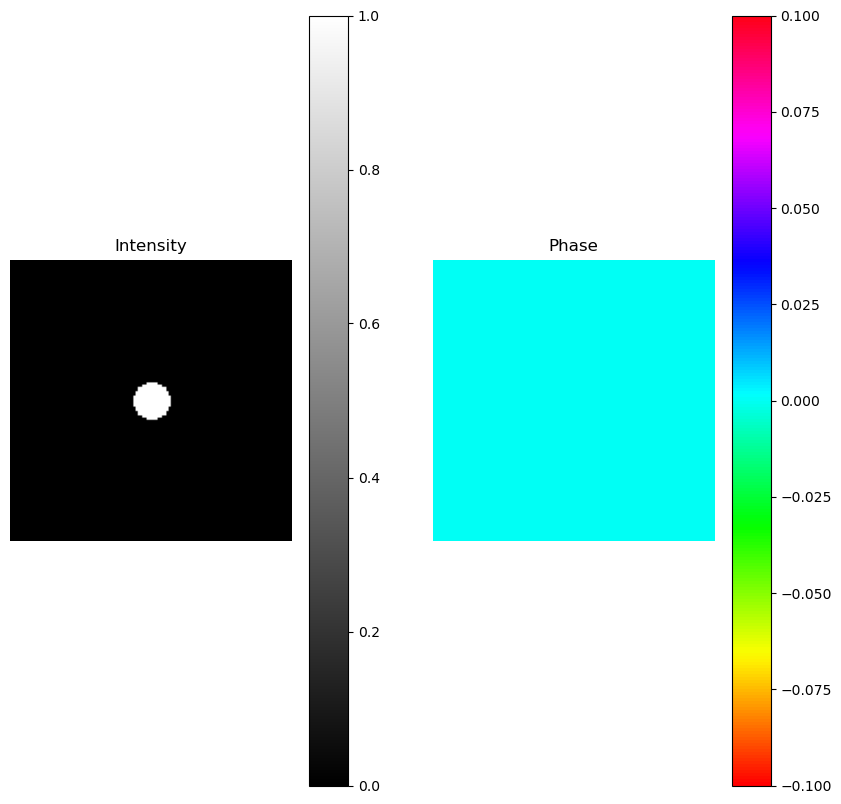

In [190]:
spotty = pupil_function(r, 0.1*mm)
TotInt(spotty)

Defining multiple spots

[-0.0007909979298191896, 3.503304914775733e-05, 0.0012624165503227406]


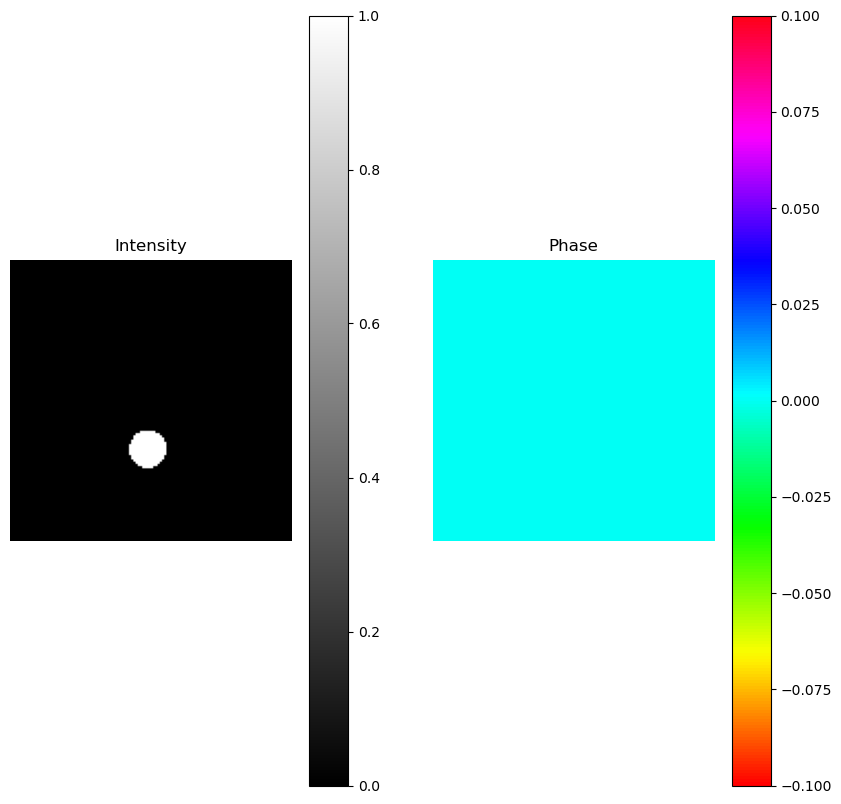

In [191]:
num_of_output_chans = 3

def output_chan(X, Y, rad_spot, maxx, num_of_spots):
    N = len(X)
    spot_loc_x = []
    spot_loc_y = []
    
    for ii in range(num_of_spots):
        spot_loc_x.append(np.random.uniform(-maxx+rad_spot,maxx-rad_spot))
        spot_loc_y.append(np.random.uniform(-maxx+rad_spot,maxx-rad_spot))
    
    print(spot_loc_x)
    
    fields = np.empty((num_of_spots, N, N), dtype=np.complex64)
    # Space definition 
    for ii in range(num_of_spots):
        X=np.linspace(-maxx,maxx,N) + spot_loc_x[ii]
        Y=np.linspace(-maxx,maxx,N) + spot_loc_y[ii]
        h=np.abs(X[1]-X[2]) # Step size
        xx,yy=np.meshgrid(X,Y)
        r, phi= cart2pol(xx,yy)
        
        fields[ii] = pupil_function(r, rad_spot)
    
    return fields, spot_loc_x, spot_loc_y # In principle, it suffices to return fields. 

output_chans, spot_loc_x, spot_loc_y = output_chan(X,Y,0.2*mm,maxx,num_of_output_chans)
TotInt(output_chans[1])

Generating the LG beam 

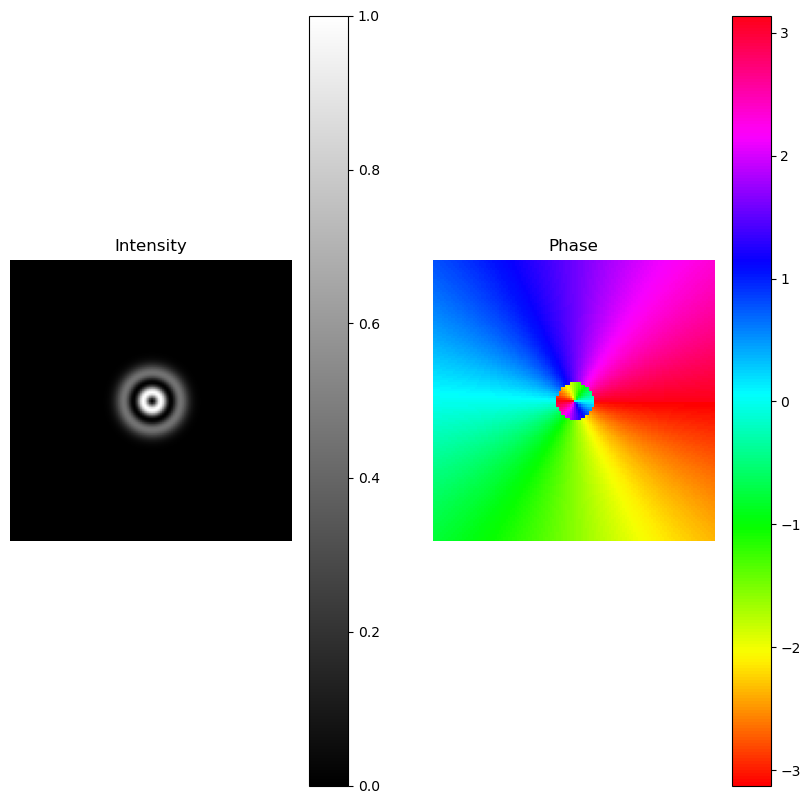

In [192]:
# Generating an LG mode as a test
field = LG(r, phi, 1, 1, 0.1*mm,h,0,k)
field = field / np.max(np.abs(field))
TotInt(field)

Let's get knotty

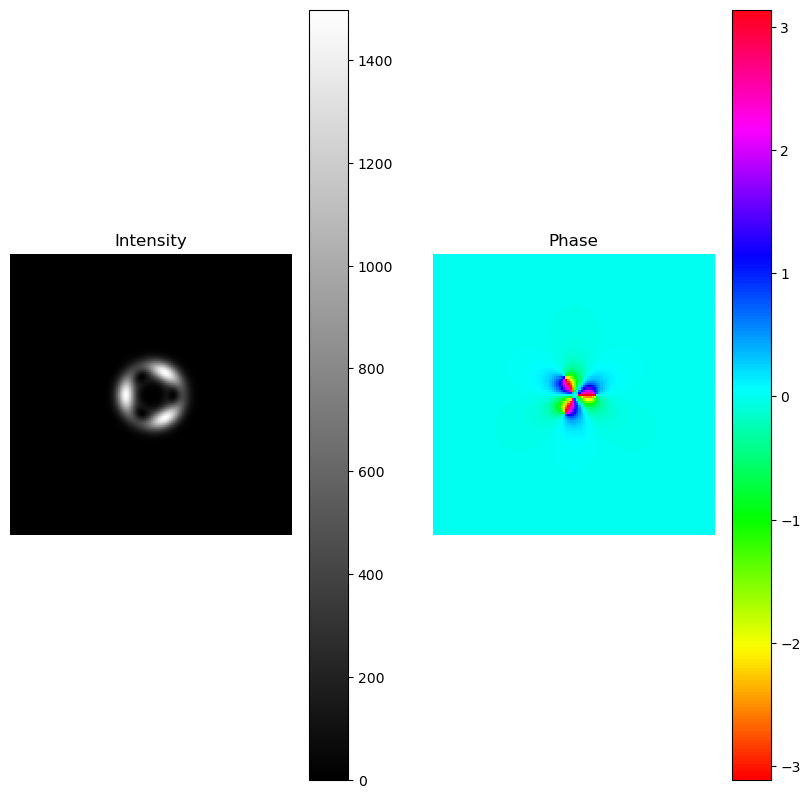

In [193]:
shapeParams = [1,1,1.2]
knotType = 'Trefoil'
w0 = 0.05*mm

# setKnotType(rr, phi, w0,  knotType, shapeParams)
field = setKnotType(r, phi, w0, knotType, shapeParams)
TotInt(field)

Now we propagate the beam towards the fourier length of the lens. Note that we are using Fraunhofer diffraction as we don't have to sample nearly as much. The solution of a beam propagating through a lens also comes out directly w/ z= the focal length of the lens. Here, we assume that the beam is in the back fourier plane. 

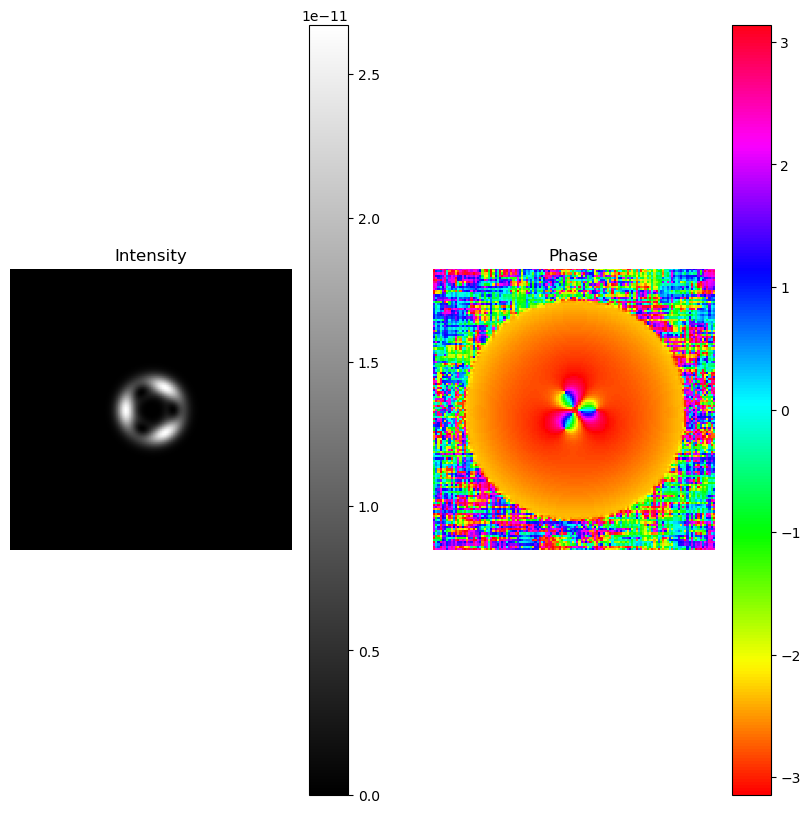

In [194]:
temp_1 = field
prop_dist = 10*cm

# Propagate the lens field to the focal plain of the lens

field_lens,_ = propFF(temp_1, maxx, la, prop_dist)

field_lens = field_lens/np.max(np.abs(field_lens))

# Propagate again immediately before the second lens

field_lens_2 = propFF(field_lens, maxx, la, prop_dist, isInverse=True)[0]

TotInt(field_lens_2)

To verify that what we see adds up, let's actually just compute the phase of the (inverse) fourier transform

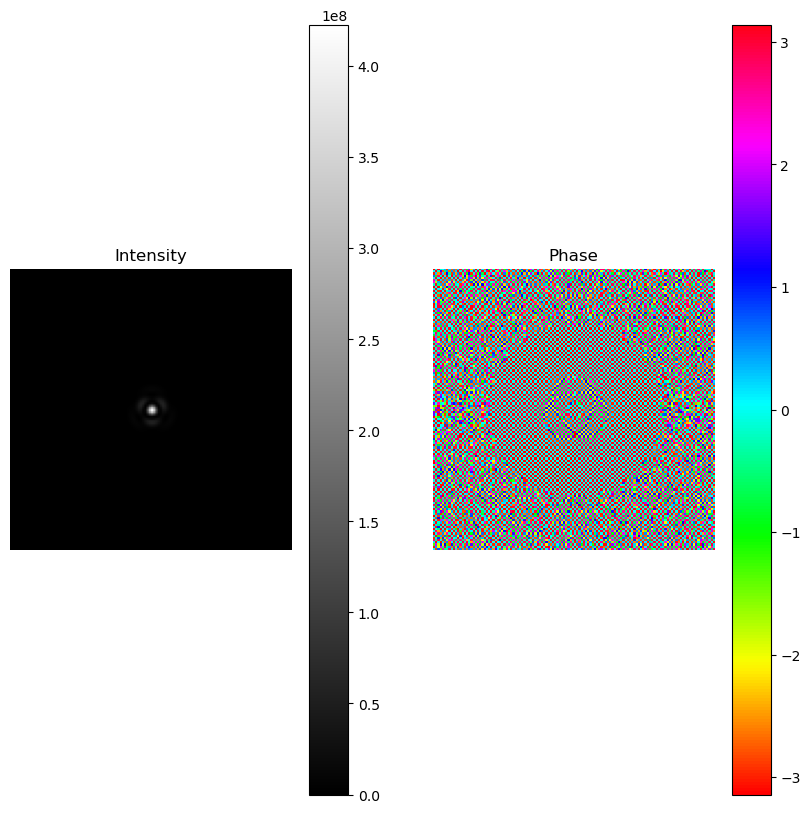

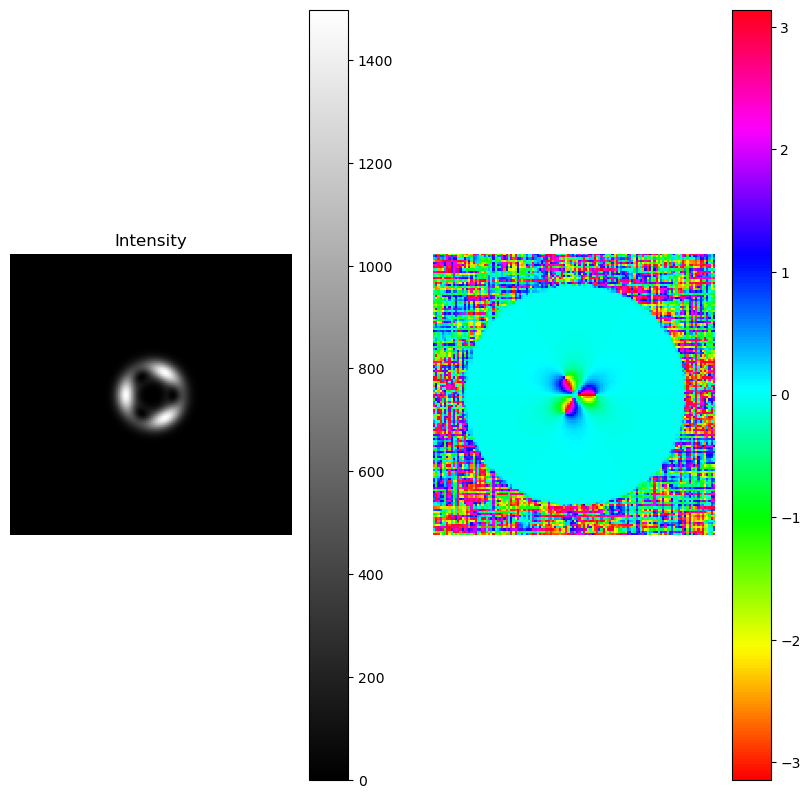

In [195]:
fourField = fftshift(fft2(temp_1))
invFourField = ifft2(ifftshift(fourField))
TotInt(fourField)
TotInt(invFourField)

# Computing the Sorting Probability

We'll need to define the fitness function, which is the sorting performance. For testing purposes, let's define a field having a gaussian beam at one of the three output_channels

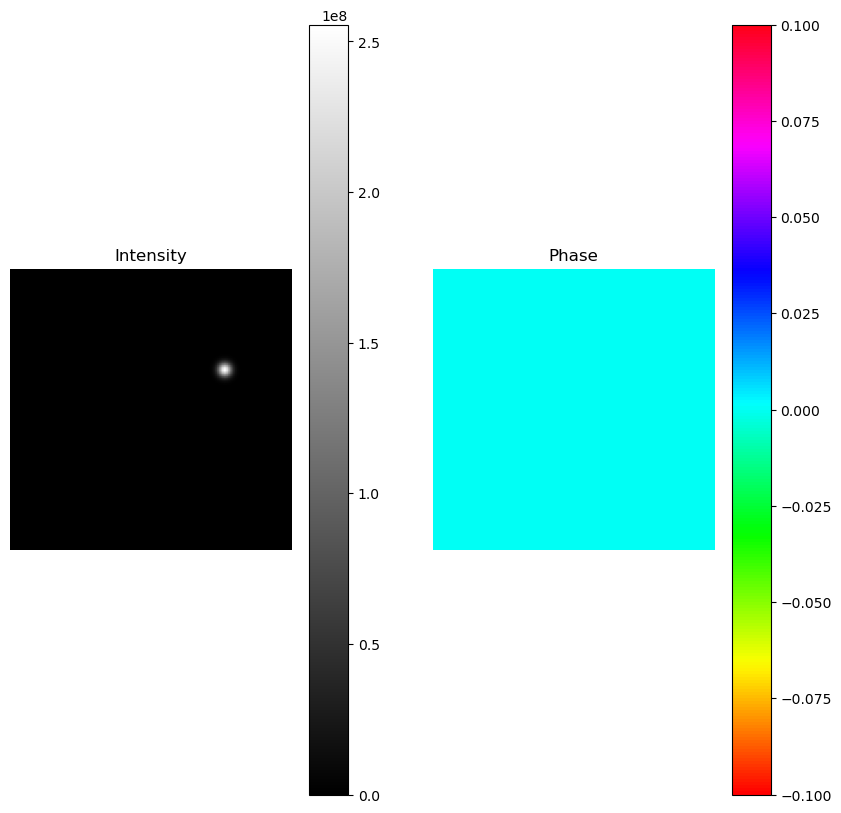

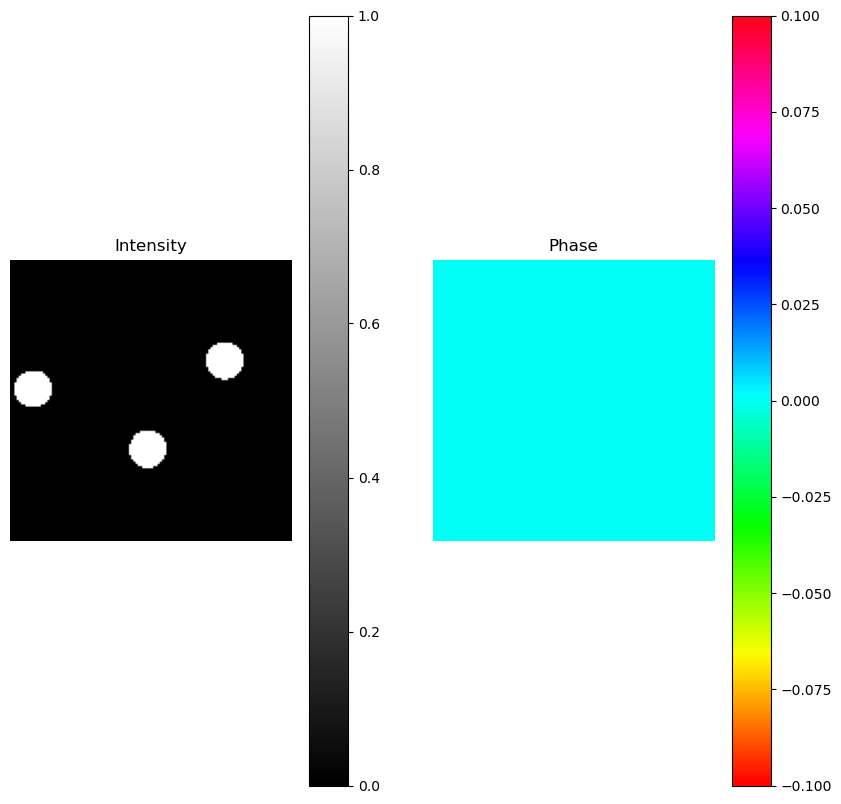

In [196]:
X_gauss=np.linspace(-maxx,maxx,N) + spot_loc_x[0]
Y_gauss=np.linspace(-maxx,maxx,N) + spot_loc_y[0]

h_gauss=np.abs(X[1]-X[2]) # Step size
xx_gauss,yy_gauss=np.meshgrid(X_gauss,Y_gauss)
r_gauss, phi_gauss= cart2pol(xx_gauss,yy_gauss)

# plotting the gaussian field 
gauss_field = LG(r_gauss, phi_gauss, 0, 0, 0.1*mm,h,0,k)
TotInt(gauss_field)
TotInt(np.sum(output_chans, axis=0))

We now compute the sorting performance. This can be done by taking the incident field and convolving it with the pupil array. 

In [197]:
# To normalize, we define the maximum sorting performance, which is the sum of intensities of each output channel

# max_output_intensity = np.sum(output_chans)

# plt.imshow(output_chans[0])

sorting_performance = 0 
ii = 0 # This defines mode n

# Define full set of indices, as you would summing through a for loop

full_index = np.arange(len(output_chans))   

# Delete ii from the list of full_index, creating a new temporary array
temp_index = np.delete(full_index, ii)
# Sum up the "incorrect" channels 
incorrect_chans = 0
for ind in temp_index:
    field_in_pupil = gauss_field*output_chans[ind]
    incorrect_chans += np.abs(field_in_pupil)**2
# Now, evaluate the sorting performance 
sorting_performance += np.abs(gauss_field*output_chans[ii])**2 - incorrect_chans 

# Genetic Algorithm

In [198]:
# Let's define a class that holds an OAM mode and its correponding output channel, defined from its centre

class oamModes():
    def __init__(self, oamBeam, output_chan_field):
        self.oamBeam = oamBeam 
        self.output_chan_field = output_chan_field

        

Create an array consisting of n OAM elements and m output channels

In [199]:
num_of_output_chans = 3
output_chans, spot_loc_x, spot_loc_y = output_chan(X,Y,0.1*mm,maxx,num_of_output_chans)

# Now create a list containing 'oamMode' objects 

list_of_OAMs = [oamModes(LG(r, phi, 1, 0, 0.2*mm,h,0,k), output_chans[0]), oamModes(LG(r, phi, -1, 0, 0.2*mm,h,0,k), output_chans[1])]

#field = LG(r, phi, 1, 0, 0.2*mm,h,0,k)
#TotInt(field)

[-0.000557508938945821, 0.000704845465963956, 0.000974157590820841]


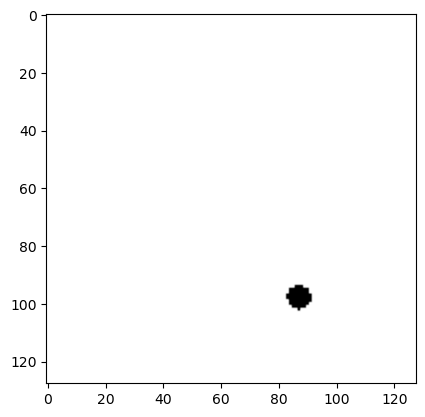

In [200]:
plt.imshow(np.abs(output_chans[0])**2, cmap = 'Greys')


We ... flatten them???

In [201]:
random_phase_modulation_1 = np.random.uniform(-np.pi, np.pi, size=(N,N))
random_phase_modulation_2 = np.random.uniform(-np.pi, np.pi, size=(N,N))

flattened_phase_1 = random_phase_modulation_1.flatten()
flattened_phase_2 = random_phase_modulation_2.flatten()


Define the fitness function. This will be the sorting performance function that we computed earlier

In [202]:
fourier_lens = 10*cm 

# Compute output channels

# num_of_output_chans = 2

# output_chans, _, _ = output_chan(X,Y,0.2*mm,maxx,num_of_output_chans)

def fitness_func(ga_instance, solution, solution_idx):

    # Create the phase map by reshaping the solution array

    reshape_phase_1 = np.reshape(a=solution[0:N**2], newshape = (N,N))
    reshape_phase_2 = np.reshape(a=solution[N**2:2*N**2], newshape=(N,N))
    phase_map_1 = np.exp(1j*reshape_phase_1)
    phase_map_2 = np.exp(1j*reshape_phase_2)
    
    # Now, this is the fitness parameter 

    sorting_performance = 0  

    for ii in range(len(list_of_OAMs)):

        # Define initial OAM field and correct output channel 

        field = list_of_OAMs[ii].oamBeam 

        # modulate the field by the first phase map 

        field_mod_1 = field*phase_map_1

        # let's simulate the propagation of the lens

        field_lens, _ = propFF(field_mod_1,maxx,la,fourier_lens)

        # modulate the field by the second phase map 

        field_mod_2 = field_lens*phase_map_2

        # simulate the lens field again. This is the final field. 

        field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)

        # compute the field intensity 

        final_field_int = np.abs(field_lens_2)**2

        # Define full set of indices, as you would summing through a for loop

        full_index = np.arange(len(output_chans))   

        # Delete ii from the list of full_index, creating a new temporary array

        temp_index = np.delete(full_index, ii)

        # Sum up the "incorrect" channels 

        incorrect_chans = 0

        for ind in temp_index:
            field_in_pupil = final_field_int*output_chans[ind]
            incorrect_chans += np.abs(field_in_pupil)**2

        # Now, evaluate the sorting performance 

        correct_chans = np.abs(final_field_int*output_chans[ii])**2

        sorting_performance += correct_chans - incorrect_chans 

    return np.mean(sorting_performance)
    

Parameters for the genetic algorithm. For ease, we store them in a yaml file. 

In [203]:
import pygad
import yaml 
from yaml import Loader 

num_generations = 100000
num_parents_mating =  2

fitness_function = fitness_func 

sol_per_pop = 10 # number of parents in the population?? 
num_genes = 2*len(flattened_phase_1) # This would refer to the number of parameters in our DNA

# Lower and upper-bound ranges of the parameterization. 

init_range_low = -np.pi
init_range_high = np.pi

parent_selection_type = "rank"
#K_tournament = 5 # number of contestants, essentially
#keep_elitism  = 1

crossover_type = "single_point"

mutation_type = "random"
mutation_percent_genes = 10 # probability of mutation 

# This function keeps track of the generation number + best fitness

def on_gen(ga_instance):
    print("Generation : ", ga_instance.generations_completed)
    print("Fitness of the best solution :", ga_instance.best_solution()[1])
    
    # Checkpoint current best model?
    
    instance_name = 'first_trial'
    ga_instance.save(filename=f'genetic_instances/{instance_name}')
    
    # Save plot every 100 generations 
    
    if (ga_instance.generations_completed % 100 == 0):
        plt.figure()
        plt.plot(ga_instance.best_solutions_fitness)
        plt.savefig(f"plots/fitness_{ga_instance.generations_completed}.jpg")
        plt.show()
        


Create the GA instance

In [204]:
ga_instance = pygad.GA(num_generations=num_generations,
                       num_parents_mating=num_parents_mating,
                       fitness_func=fitness_function,
                       sol_per_pop=sol_per_pop,
                       num_genes=num_genes,
                       init_range_low=init_range_low,
                       init_range_high=init_range_high,
                       parent_selection_type=parent_selection_type,
                       crossover_type=crossover_type,
                       mutation_type=mutation_type,
                       mutation_percent_genes=mutation_percent_genes,
                       on_generation=on_gen)

Now run the GA

Generation :  4808
Fitness of the best solution : 6272236.141714939
Generation :  4809
Fitness of the best solution : 6272236.141714939
Generation :  4810
Fitness of the best solution : 6272236.141714939
Generation :  4811
Fitness of the best solution : 6272236.141714939
Generation :  4812
Fitness of the best solution : 6272236.141714939
Generation :  4813
Fitness of the best solution : 6272236.141714939
Generation :  4814
Fitness of the best solution : 6272236.141714939
Generation :  4815
Fitness of the best solution : 6272236.141714939
Generation :  4816
Fitness of the best solution : 6272236.141714939
Generation :  4817
Fitness of the best solution : 6272236.141714939
Generation :  4818
Fitness of the best solution : 6272236.141714939
Generation :  4819
Fitness of the best solution : 6272236.141714939
Generation :  4820
Fitness of the best solution : 6272236.141714939
Generation :  4821
Fitness of the best solution : 6272236.141714939
Generation :  4822
Fitness of the best solution 

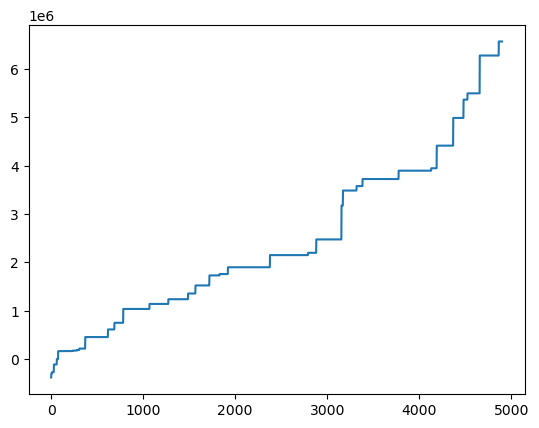

Generation :  4901
Fitness of the best solution : 6562135.74756691
Generation :  4902
Fitness of the best solution : 6562135.74756691
Generation :  4903
Fitness of the best solution : 6562135.74756691
Generation :  4904
Fitness of the best solution : 6562135.74756691
Generation :  4905
Fitness of the best solution : 6562135.74756691
Generation :  4906
Fitness of the best solution : 6562135.74756691
Generation :  4907
Fitness of the best solution : 6562135.74756691
Generation :  4908
Fitness of the best solution : 6562135.74756691
Generation :  4909
Fitness of the best solution : 6562135.74756691
Generation :  4910
Fitness of the best solution : 6562135.74756691
Generation :  4911
Fitness of the best solution : 6702796.923931428
Generation :  4912
Fitness of the best solution : 6756194.87103966
Generation :  4913
Fitness of the best solution : 6756194.87103966
Generation :  4914
Fitness of the best solution : 6756194.87103966
Generation :  4915
Fitness of the best solution : 6756194.871

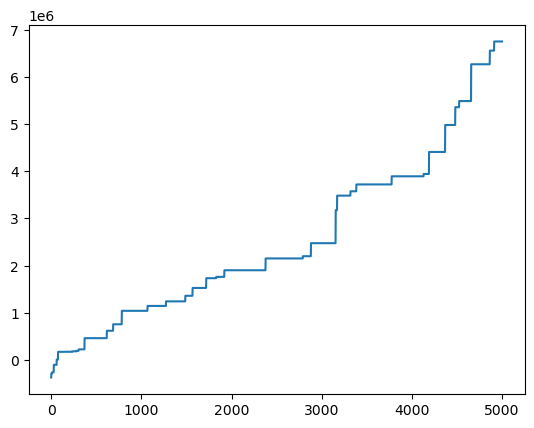

Generation :  5001
Fitness of the best solution : 6756194.87103966
Generation :  5002
Fitness of the best solution : 6756194.87103966
Generation :  5003
Fitness of the best solution : 6756194.87103966
Generation :  5004
Fitness of the best solution : 6756194.87103966
Generation :  5005
Fitness of the best solution : 6756194.87103966
Generation :  5006
Fitness of the best solution : 6756194.87103966
Generation :  5007
Fitness of the best solution : 6756194.87103966
Generation :  5008
Fitness of the best solution : 6756194.87103966
Generation :  5009
Fitness of the best solution : 6756194.87103966
Generation :  5010
Fitness of the best solution : 6756194.87103966
Generation :  5011
Fitness of the best solution : 6756194.87103966
Generation :  5012
Fitness of the best solution : 6756194.87103966
Generation :  5013
Fitness of the best solution : 6756194.87103966
Generation :  5014
Fitness of the best solution : 6756194.87103966
Generation :  5015
Fitness of the best solution : 6756194.8710

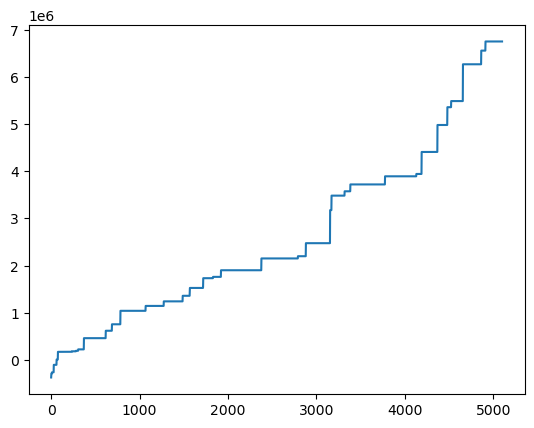

Generation :  5101
Fitness of the best solution : 6756194.87103966
Generation :  5102
Fitness of the best solution : 6756194.87103966
Generation :  5103
Fitness of the best solution : 6756194.87103966
Generation :  5104
Fitness of the best solution : 6756194.87103966
Generation :  5105
Fitness of the best solution : 6756194.87103966
Generation :  5106
Fitness of the best solution : 6756194.87103966
Generation :  5107
Fitness of the best solution : 6756194.87103966
Generation :  5108
Fitness of the best solution : 6756194.87103966
Generation :  5109
Fitness of the best solution : 6756194.87103966
Generation :  5110
Fitness of the best solution : 6756194.87103966
Generation :  5111
Fitness of the best solution : 6756194.87103966
Generation :  5112
Fitness of the best solution : 6756194.87103966
Generation :  5113
Fitness of the best solution : 6756194.87103966
Generation :  5114
Fitness of the best solution : 6756194.87103966
Generation :  5115
Fitness of the best solution : 6756194.8710

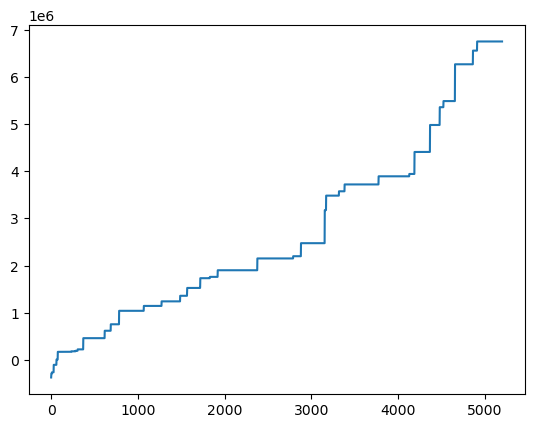

Generation :  5201
Fitness of the best solution : 6756194.87103966
Generation :  5202
Fitness of the best solution : 6756194.87103966
Generation :  5203
Fitness of the best solution : 6756194.87103966
Generation :  5204
Fitness of the best solution : 6756194.87103966
Generation :  5205
Fitness of the best solution : 6756194.87103966
Generation :  5206
Fitness of the best solution : 6756194.87103966
Generation :  5207
Fitness of the best solution : 6756194.87103966
Generation :  5208
Fitness of the best solution : 6756194.87103966
Generation :  5209
Fitness of the best solution : 6756194.87103966
Generation :  5210
Fitness of the best solution : 6756194.87103966
Generation :  5211
Fitness of the best solution : 6756194.87103966
Generation :  5212
Fitness of the best solution : 6756194.87103966
Generation :  5213
Fitness of the best solution : 6756194.87103966
Generation :  5214
Fitness of the best solution : 6756194.87103966
Generation :  5215
Fitness of the best solution : 6756194.8710

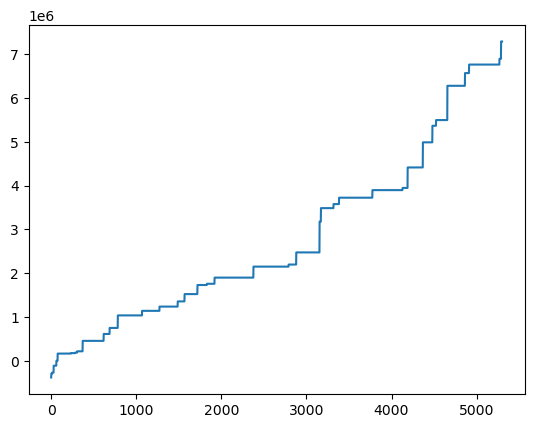

Generation :  5301
Fitness of the best solution : 7282349.89747916
Generation :  5302
Fitness of the best solution : 7282349.89747916
Generation :  5303
Fitness of the best solution : 7282349.89747916
Generation :  5304
Fitness of the best solution : 7282349.89747916
Generation :  5305
Fitness of the best solution : 7282349.89747916
Generation :  5306
Fitness of the best solution : 7282349.89747916
Generation :  5307
Fitness of the best solution : 7282349.89747916
Generation :  5308
Fitness of the best solution : 7282349.89747916
Generation :  5309
Fitness of the best solution : 7282349.89747916
Generation :  5310
Fitness of the best solution : 7282349.89747916
Generation :  5311
Fitness of the best solution : 7282349.89747916
Generation :  5312
Fitness of the best solution : 7282349.89747916
Generation :  5313
Fitness of the best solution : 7282349.89747916
Generation :  5314
Fitness of the best solution : 7282349.89747916
Generation :  5315
Fitness of the best solution : 7282349.8974

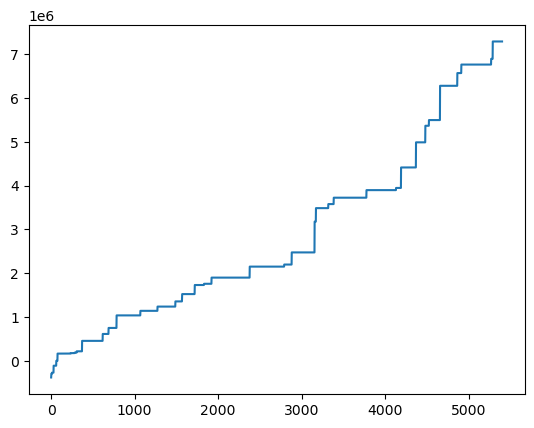

Generation :  5401
Fitness of the best solution : 7282349.89747916
Generation :  5402
Fitness of the best solution : 7282349.89747916
Generation :  5403
Fitness of the best solution : 7282349.89747916
Generation :  5404
Fitness of the best solution : 7282349.89747916
Generation :  5405
Fitness of the best solution : 7282349.89747916
Generation :  5406
Fitness of the best solution : 7282349.89747916
Generation :  5407
Fitness of the best solution : 7282349.89747916
Generation :  5408
Fitness of the best solution : 7282349.89747916
Generation :  5409
Fitness of the best solution : 7282349.89747916
Generation :  5410
Fitness of the best solution : 7282349.89747916
Generation :  5411
Fitness of the best solution : 7282349.89747916
Generation :  5412
Fitness of the best solution : 7282349.89747916
Generation :  5413
Fitness of the best solution : 7282349.89747916
Generation :  5414
Fitness of the best solution : 7282349.89747916
Generation :  5415
Fitness of the best solution : 7282349.8974

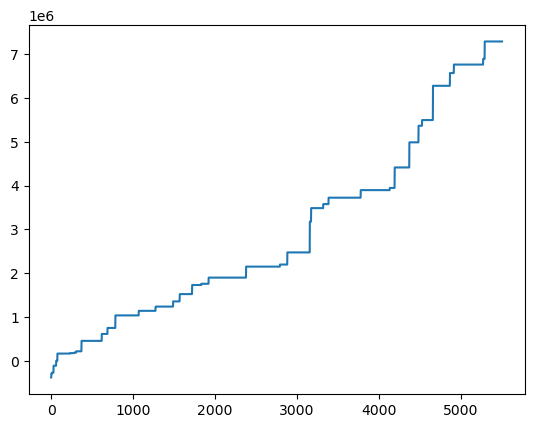

Generation :  5501
Fitness of the best solution : 7282349.89747916
Generation :  5502
Fitness of the best solution : 7282349.89747916
Generation :  5503
Fitness of the best solution : 7282349.89747916
Generation :  5504
Fitness of the best solution : 7282349.89747916
Generation :  5505
Fitness of the best solution : 7282349.89747916
Generation :  5506
Fitness of the best solution : 7282349.89747916
Generation :  5507
Fitness of the best solution : 7282349.89747916
Generation :  5508
Fitness of the best solution : 7282349.89747916
Generation :  5509
Fitness of the best solution : 7282349.89747916
Generation :  5510
Fitness of the best solution : 7282349.89747916
Generation :  5511
Fitness of the best solution : 7282349.89747916
Generation :  5512
Fitness of the best solution : 7282349.89747916
Generation :  5513
Fitness of the best solution : 7282349.89747916
Generation :  5514
Fitness of the best solution : 7282349.89747916
Generation :  5515
Fitness of the best solution : 7282349.8974

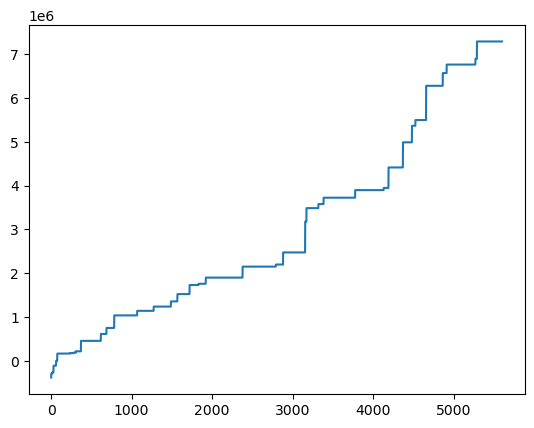

Generation :  5601
Fitness of the best solution : 7282349.89747916
Generation :  5602
Fitness of the best solution : 7282349.89747916
Generation :  5603
Fitness of the best solution : 7282349.89747916
Generation :  5604
Fitness of the best solution : 7282349.89747916
Generation :  5605
Fitness of the best solution : 7282349.89747916
Generation :  5606
Fitness of the best solution : 7282349.89747916
Generation :  5607
Fitness of the best solution : 7282349.89747916
Generation :  5608
Fitness of the best solution : 7282349.89747916
Generation :  5609
Fitness of the best solution : 7282349.89747916
Generation :  5610
Fitness of the best solution : 7282349.89747916
Generation :  5611
Fitness of the best solution : 7282349.89747916
Generation :  5612
Fitness of the best solution : 7282349.89747916
Generation :  5613
Fitness of the best solution : 7282349.89747916
Generation :  5614
Fitness of the best solution : 7282349.89747916
Generation :  5615
Fitness of the best solution : 7282349.8974

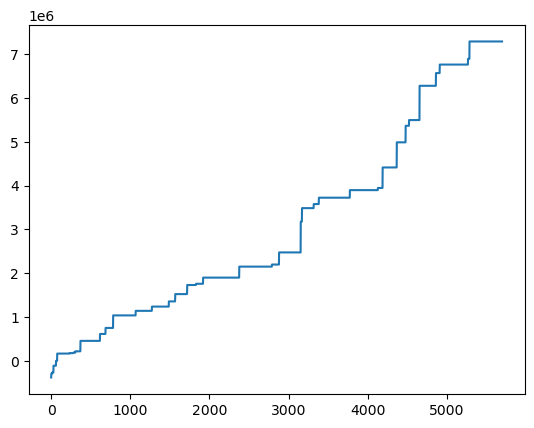

Generation :  5701
Fitness of the best solution : 7282349.89747916
Generation :  5702
Fitness of the best solution : 7282349.89747916
Generation :  5703
Fitness of the best solution : 7282349.89747916
Generation :  5704
Fitness of the best solution : 7282349.89747916
Generation :  5705
Fitness of the best solution : 7282349.89747916
Generation :  5706
Fitness of the best solution : 7282349.89747916
Generation :  5707
Fitness of the best solution : 7282349.89747916
Generation :  5708
Fitness of the best solution : 7282349.89747916
Generation :  5709
Fitness of the best solution : 7282349.89747916
Generation :  5710
Fitness of the best solution : 7282349.89747916
Generation :  5711
Fitness of the best solution : 7282349.89747916
Generation :  5712
Fitness of the best solution : 7282349.89747916
Generation :  5713
Fitness of the best solution : 7282349.89747916
Generation :  5714
Fitness of the best solution : 7282349.89747916
Generation :  5715
Fitness of the best solution : 7282349.8974

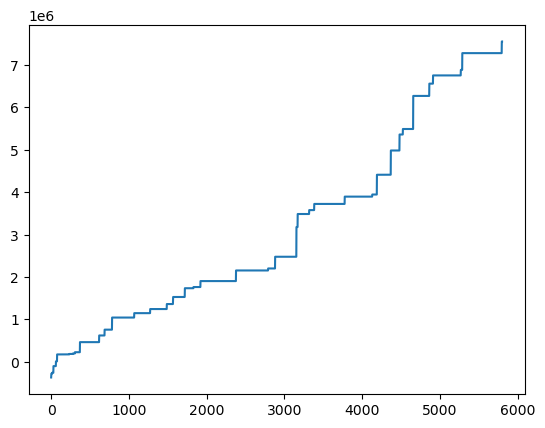

Generation :  5801
Fitness of the best solution : 7557592.595741761
Generation :  5802
Fitness of the best solution : 7557592.595741761
Generation :  5803
Fitness of the best solution : 7557592.595741761
Generation :  5804
Fitness of the best solution : 7557592.595741761
Generation :  5805
Fitness of the best solution : 7557592.595741761
Generation :  5806
Fitness of the best solution : 7557592.595741761
Generation :  5807
Fitness of the best solution : 7557592.595741761
Generation :  5808
Fitness of the best solution : 7557592.595741761
Generation :  5809
Fitness of the best solution : 7557592.595741761
Generation :  5810
Fitness of the best solution : 7557592.595741761
Generation :  5811
Fitness of the best solution : 7557592.595741761
Generation :  5812
Fitness of the best solution : 7557592.595741761
Generation :  5813
Fitness of the best solution : 7557592.595741761
Generation :  5814
Fitness of the best solution : 7557592.595741761
Generation :  5815
Fitness of the best solution 

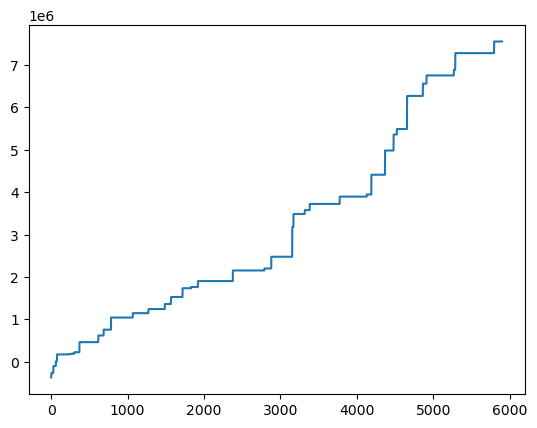

Generation :  5901
Fitness of the best solution : 7557592.595741761
Generation :  5902
Fitness of the best solution : 7557592.595741761
Generation :  5903
Fitness of the best solution : 7557592.595741761
Generation :  5904
Fitness of the best solution : 7557592.595741761
Generation :  5905
Fitness of the best solution : 7557592.595741761
Generation :  5906
Fitness of the best solution : 7557592.595741761
Generation :  5907
Fitness of the best solution : 7557592.595741761
Generation :  5908
Fitness of the best solution : 7557592.595741761
Generation :  5909
Fitness of the best solution : 7557592.595741761
Generation :  5910
Fitness of the best solution : 7557592.595741761
Generation :  5911
Fitness of the best solution : 7557592.595741761
Generation :  5912
Fitness of the best solution : 7557592.595741761
Generation :  5913
Fitness of the best solution : 7557592.595741761
Generation :  5914
Fitness of the best solution : 7557592.595741761
Generation :  5915
Fitness of the best solution 

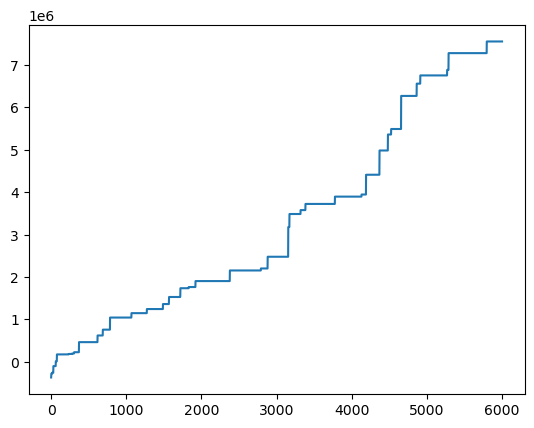

Generation :  6001
Fitness of the best solution : 7557592.595741761
Generation :  6002
Fitness of the best solution : 7557592.595741761
Generation :  6003
Fitness of the best solution : 7557592.595741761
Generation :  6004
Fitness of the best solution : 7557592.595741761
Generation :  6005
Fitness of the best solution : 7842826.545197021
Generation :  6006
Fitness of the best solution : 7842826.545197021
Generation :  6007
Fitness of the best solution : 7842826.545197021
Generation :  6008
Fitness of the best solution : 7842826.545197021
Generation :  6009
Fitness of the best solution : 7842826.545197021
Generation :  6010
Fitness of the best solution : 7842826.545197021
Generation :  6011
Fitness of the best solution : 7842826.545197021
Generation :  6012
Fitness of the best solution : 7842826.545197021
Generation :  6013
Fitness of the best solution : 7842826.545197021
Generation :  6014
Fitness of the best solution : 7842826.545197021
Generation :  6015
Fitness of the best solution 

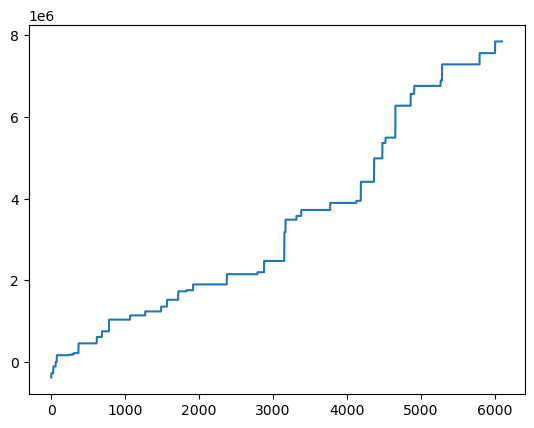

Generation :  6101
Fitness of the best solution : 7842826.545197021
Generation :  6102
Fitness of the best solution : 7842826.545197021
Generation :  6103
Fitness of the best solution : 7842826.545197021
Generation :  6104
Fitness of the best solution : 7842826.545197021
Generation :  6105
Fitness of the best solution : 7842826.545197021
Generation :  6106
Fitness of the best solution : 7842826.545197021
Generation :  6107
Fitness of the best solution : 7842826.545197021
Generation :  6108
Fitness of the best solution : 7842826.545197021
Generation :  6109
Fitness of the best solution : 7842826.545197021
Generation :  6110
Fitness of the best solution : 7842826.545197021
Generation :  6111
Fitness of the best solution : 7842826.545197021
Generation :  6112
Fitness of the best solution : 7842826.545197021
Generation :  6113
Fitness of the best solution : 7842826.545197021
Generation :  6114
Fitness of the best solution : 7842826.545197021
Generation :  6115
Fitness of the best solution 

KeyboardInterrupt: 

In [216]:
import matplotlib.pyplot as plt

ga_instance.run()
ga_instance.plot_fitness()
plt.savefig('plots/figgy.png')

# Analyzing the Solution of the GA 

extract the solution, and reshape it in an interpretable form 

In [206]:
solution, solution_fitness, solution_idx = ga_instance.best_solution()
print("Parameters of the best solution : {solution}".format(solution=solution))
print("Fitness value of the best solution = {solution_fitness}".format(solution_fitness=solution_fitness))


Parameters of the best solution : [-0.43465051 13.0485164   2.97504114 ...  0.45608073 -1.47659929
 -9.57480969]
Fitness value of the best solution = 6272236.141714939


Save the genetic instance

In [137]:
instance_name = 'first_trial'
ga_instance.save(filename=f'genetic_instances/{instance_name}')

Let's analyze what we've made

In [213]:
# Let's pick an LG beam to analyze

field = list_of_OAMs[1].oamBeam 

# Create the phase map by reshaping the solution array

reshape_phase_1 = np.reshape(a=solution[0:N**2], newshape = (N,N))
reshape_phase_2 = np.reshape(a=solution[N**2:2*N**2], newshape=(N,N))
phase_map_1 = np.exp(1j*reshape_phase_1)
phase_map_2 = np.exp(1j*reshape_phase_2)

# modulate the field by the first phase map 

field_mod_1 = field*phase_map_1

# let's simulate the propagation of the lens

field_lens, _ = propFF(field_mod_1,maxx,la,fourier_lens)

# modulate the field by the second phase map 

field_mod_2 = field_lens*phase_map_2

# simulate the lens field again. This is the final field. 

field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)

# compute the field intensity 

final_field_int = np.abs(field_lens_2)**2

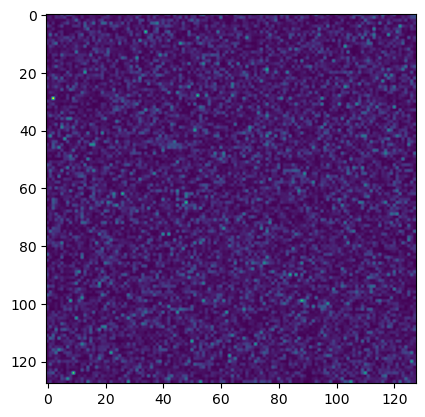

In [214]:
plt.imshow(final_field_int)

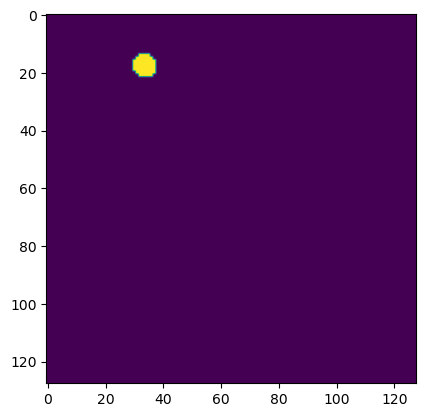

In [215]:

plt.imshow(np.abs(output_chans[1])**2)